In [85]:
import warnings
warnings.filterwarnings('ignore')

Task 1: Exploratory Data Analysis (EDA)

In [86]:
# load dataset
import pandas as pd

df=pd.read_csv('/content/mushroom.csv')

In [87]:
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [88]:
df.shape

(2000, 26)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 
 14  stalk_co

In [90]:
# checking for null values
df.isnull().sum()

,0
Unnamed: 0,0
cap_shape,0
cap_surface,0
cap_color,0
bruises,0
odor,0
gill_attachment,0
gill_spacing,0
gill_size,0
gill_color,0


In [91]:
# checking for duplicates
df.duplicated().any()

True

In [92]:
df[df.duplicated]

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
34,1279,bell,smooth,pink,no,foul,notched,distant,broad,pink,...,universal,brown,one,zone,black,scattered,leaves,poisonous,5.291009,5.436304
70,1275,sunken,scaly,yellow,no,pungent,descending,distant,narrow,orange,...,partial,white,none,zone,white,numerous,leaves,poisonous,4.746453,10.769935
76,549,conical,grooves,brown,no,foul,free,distant,broad,white,...,partial,yellow,two,large,chocolate,solitary,woods,poisonous,12.206952,5.061715
109,1198,sunken,smooth,white,no,anise,attached,crowded,broad,black,...,partial,brown,two,sheathing,black,solitary,woods,edible,13.214007,14.549171
127,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,618,flat,grooves,green,yes,musty,notched,crowded,broad,chocolate,...,universal,yellow,one,zone,brown,abundant,meadows,poisonous,14.834383,2.053744
1994,871,flat,scaly,pink,no,spicy,attached,distant,narrow,red,...,universal,brown,two,zone,brown,abundant,meadows,poisonous,4.794826,4.576464
1995,863,sunken,scaly,brown,yes,foul,attached,crowded,narrow,chocolate,...,partial,orange,one,flaring,purple,abundant,leaves,poisonous,5.877891,17.464145
1997,265,convex,grooves,green,yes,fishy,notched,close,narrow,pink,...,partial,brown,two,evanescent,yellow,abundant,woods,poisonous,13.558064,11.270020


In [93]:
df.duplicated().value_counts()

,count
True,1024
False,976


In [94]:
# remove duplicates
df.drop_duplicates(inplace=True)

In [95]:
df.shape

(976, 26)

In [96]:
# removing unneccsary columns
df=df.drop(columns='Unnamed: 0')

<Axes: >

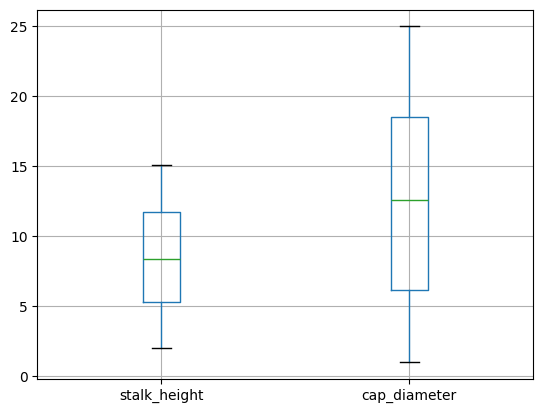

In [97]:
# checking outliers
df.boxplot()

In [98]:
df.head()

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


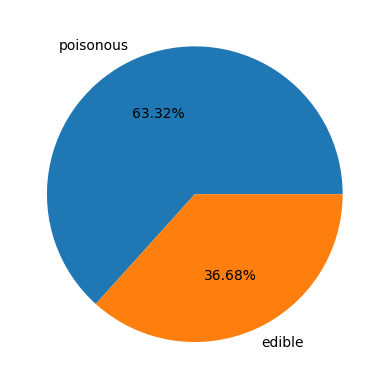

In [99]:
# data distibution
import seaborn as sns
import matplotlib.pyplot as plt

plt.pie(df['class'].value_counts(),labels=df['class'].unique(),autopct='%.2f%%')
plt.show()

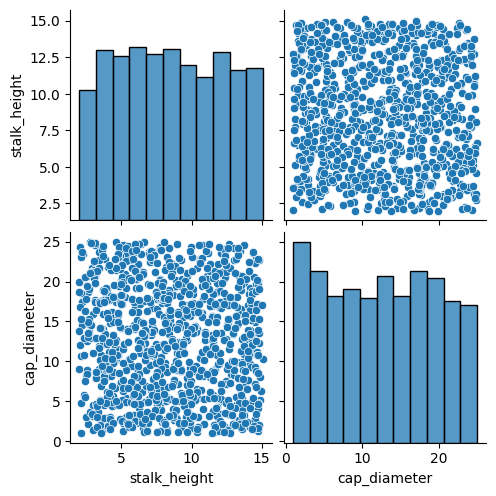

In [100]:
sns.pairplot(df)

<Axes: xlabel='cap_shape', ylabel='count'>

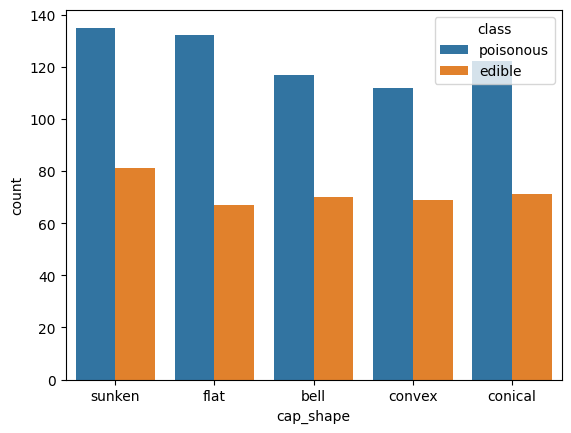

In [101]:
sns.countplot(data=df,x='cap_shape',hue='class')

<Axes: xlabel='habitat', ylabel='count'>

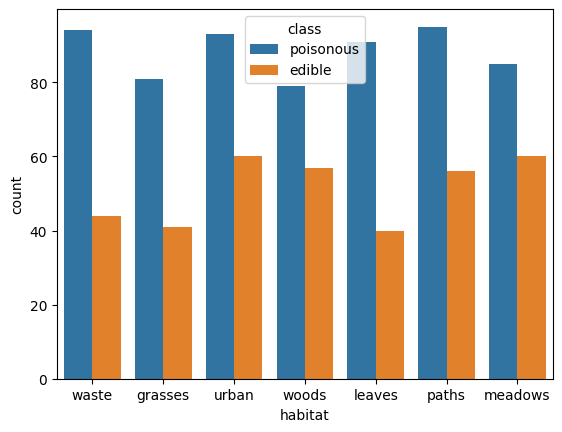

In [102]:
sns.countplot(data=df,x='habitat',hue='class')

Task 2: Data Preprocessing

In [103]:
# target is class
target=df['class']

# the rest all are features
features=df.drop(columns='class')

In [104]:
target.head()

,class
0,poisonous
1,edible
2,poisonous
3,poisonous
4,poisonous


In [105]:
features.head()

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,stalk_height,cap_diameter
0,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,...,yellow,partial,brown,two,sheathing,chocolate,clustered,waste,14.276173,5.054983
1,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,...,brown,universal,brown,two,sheathing,brown,numerous,waste,3.952715,19.068319
2,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,...,gray,universal,yellow,two,sheathing,purple,abundant,waste,9.054265,7.205884
3,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,...,pink,partial,yellow,two,cobwebby,green,clustered,grasses,5.226499,20.932692
4,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,...,white,universal,white,none,none,yellow,clustered,urban,14.037532,12.545245


In [106]:
# labeling
features=pd.get_dummies(data=features,dtype='int')

from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
target=pd.DataFrame(label.fit_transform(target),columns=['class'])

In [107]:
target.head()

,class
0,1
1,0
2,1
3,1
4,1


In [108]:
features.head()

,stalk_height,cap_diameter,cap_shape_bell,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_fibrous,cap_surface_grooves,cap_surface_scaly,...,population_scattered,population_several,population_solitary,habitat_grasses,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods
0,14.276173,5.054983,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1,3.952715,19.068319,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,1,0
2,9.054265,7.205884,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,5.226499,20.932692,1,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
4,14.037532,12.545245,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [109]:
# standartdization
from sklearn.preprocessing import MinMaxScaler

minmax=MinMaxScaler()
features=pd.DataFrame(minmax.fit_transform(features),columns=features.columns)

In [110]:
# splitting the data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.75,random_state=100)

In [111]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(732, 126)
(732, 1)
(244, 126)
(244, 1)


Task 3: Data Visualization

<Axes: xlabel='odor', ylabel='count'>

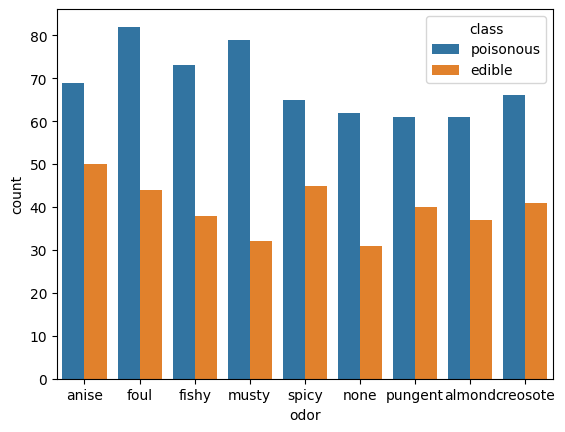

In [112]:
sns.countplot(df,x='odor',hue='class')

<Axes: xlabel='class', ylabel='count'>

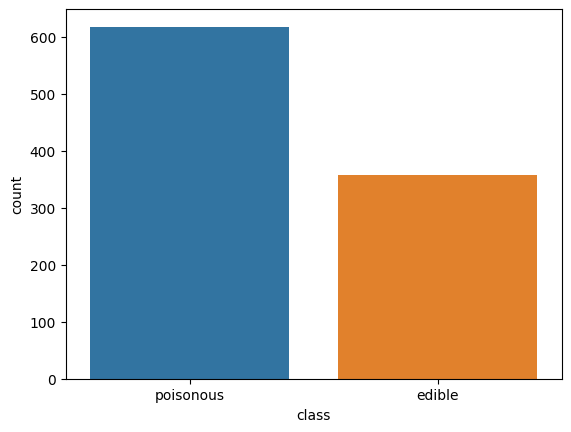

In [113]:
sns.countplot(data=df,x='class',hue='class')

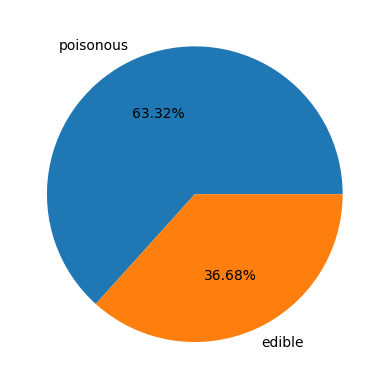

In [114]:
plt.pie(df['class'].value_counts(),labels=df['class'].unique(),autopct='%.2f%%')
plt.show()

In [115]:
# here the data distribution in class is biased because poisonous class major
# so the dataset is imbalanced.

Task 4: SVM Implementation

In [116]:
!pip install imblearn

In [117]:
from imblearn.over_sampling import SMOTE

In [118]:
smote=SMOTE()

In [119]:
x_train_s,y_train_s=smote.fit_resample(x_train,y_train)

In [120]:
y_train_s.value_counts()

,count
class,
0,474
1,474


In [121]:
from sklearn.svm import SVC

In [122]:
svc=SVC(C=2.0,kernel='rbf',gamma=0.5)

In [123]:
svc.fit(x_train_s,y_train_s)

SVC(C=2.0, gamma=0.5)

In [124]:
y_pred=svc.predict(x_test)

In [125]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.5901639344262295

In [126]:
from sklearn.metrics import confusion_matrix,classification_report

In [127]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.59      1.00      0.74       144

    accuracy                           0.59       244
   macro avg       0.30      0.50      0.37       244
weighted avg       0.35      0.59      0.44       244



Task 5: Visualization of SVM Results

In [128]:
conf=confusion_matrix(y_test,y_pred)
conf

array([[  0, 100],
       [  0, 144]])

Text(0.5, 1.0, 'confusion matrix')

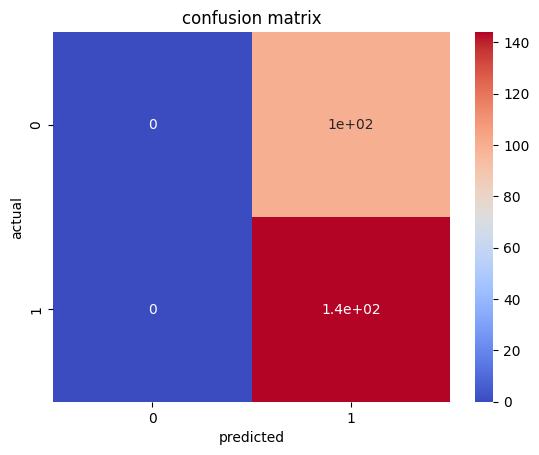

In [129]:
sns.heatmap(conf,annot=True,cmap=plt.cm.coolwarm)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')

Task 6: Parameter Tuning and Optimization

In [130]:
svc1=SVC(C=5.0,kernel='poly',gamma=0.6,degree=1)
svc1.fit(x_train_s,y_train_s)
y_pred1=svc1.predict(x_test)
accuracy_score(y_test,y_pred1)

0.44672131147540983

In [131]:
svc2=SVC(C=10.0,kernel='sigmoid',gamma=0.2)
svc2.fit(x_train_s,y_train_s)
y_pred2=svc2.predict(x_test)
accuracy_score(y_test,y_pred2)

0.5327868852459017

Task 7: Comparison and Analysis

In [132]:
#	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).

'''
Since the dataset is non linear,the kernels used are polynomial,radial basis function and sigmoid.
rbf gives the highest accuracy when it is compared to polynomial and sigmoid.
'''

'\nSince the dataset is non linear,the kernels used are polynomial,radial basis function and sigmoid.\nrbf gives the highest accuracy when it is compared to polynomial and sigmoid.\n'

In [133]:
# Analyze SVM strengths and weaknesses for the Mushroom dataset based on EDA and visualization results.
'''
Strength:
--- It handles the non-linear data well.
--- rbf is performing well for this dataset.

Weakness:
--- The dataset is imbalanced
--- The dataset contains over 50% of duplicates
'''

'\nStrength:\n--- It handles the non-linear data well.\n--- rbf is performing well for this dataset.\n\nWeakness:\n--- The dataset is imbalanced\n--- The dataset contains over 50% of duplicates\n'

In [134]:
# Discuss practical implications of SVM in real-world classification tasks.
'''
It is robust in
--- medical diagnosis,
--- image detection,
--- text detection etc.,.
'''

'\nIt is robust in \n--- medical diagnosis,\n--- image detection,\n--- text detection etc.,.\n'